# Naive Bayes Classification on Kaggle Mushroom Dataset

**Dataset Source:** [Mushroom Classification – Kaggle](https://www.kaggle.com/datasets/uciml/mushroom-classification)

**Task:** Perform the same operations as Experiment 5 (PlayTennis) on a real Kaggle dataset

**Objective:** Classify mushrooms as Edible (e) or Poisonous (p) based on categorical features

In [56]:
import kagglehub
import pandas as pd

## Step 1: Download Dataset from Kaggle

Download the mushrooms.csv file from: https://www.kaggle.com/datasets/uciml/mushroom-classification

Place it in the same directory as this notebook.

In [57]:
# Load the mushroom dataset from Kaggle
# Download latest version from Kaggle
path = kagglehub.dataset_download("uciml/mushroom-classification")
print("Path to dataset files:", path)

# The dataset contains mushrooms.csv
# Load it from the downloaded path
import os

df = pd.read_csv(os.path.join(path, 'mushrooms.csv'))

Path to dataset files: C:\Users\shaki\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


## Step 2: Exploratory Data Analysis (EDA)

In [58]:
# Check dataset shape
df.shape

(8124, 23)

In [59]:
# View first 5 rows
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [60]:
# Check for null/missing values
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [61]:
# Statistical summary
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### Target Variable Information
- **e** = Edible
- **p** = Poisonous

In [62]:
# Check target distribution
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

## Step 3: Data Preprocessing – Split Features and Target

In [63]:
# Features (all columns except 'class')
X = df.iloc[:, 1:]

# Target variable (first column 'class')
y = df.iloc[:, 0]

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (8124, 22)
Target shape: (8124,)


In [64]:
# View features
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [65]:
# View target
y.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: object

## Step 4: One-Hot Encoding for Categorical Features

Like Experiment 5, we use OneHotEncoder because:
- It handles categorical data efficiently
- GaussianNB requires numeric input
- Better than Label Encoding for categorical features

In [66]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [67]:
# Initialize OneHotEncoder
one_hot_encoded = OneHotEncoder(sparse_output=False, dtype=np.int32)

In [68]:
# Fit and transform features
X_new = one_hot_encoded.fit_transform(X)
print('Encoded features shape:', X_new.shape)

Encoded features shape: (8124, 117)


## Step 5: Train-Test Split

In [69]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test) with same random_state as Experiment 5
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 6499
Test set size: 1625


## Step 6: Train Gaussian Naive Bayes Model

In [70]:
from sklearn.naive_bayes import GaussianNB

In [71]:
# Initialize Gaussian Naive Bayes model
model = GaussianNB()

In [72]:
# Train the model
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Step 7: Make Predictions

In [73]:
# Make predictions on test set
y_pred = model.predict(X_test)

## Step 8: Model Evaluation

In [74]:
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

           e       1.00      0.92      0.96       843
           p       0.92      1.00      0.96       782

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

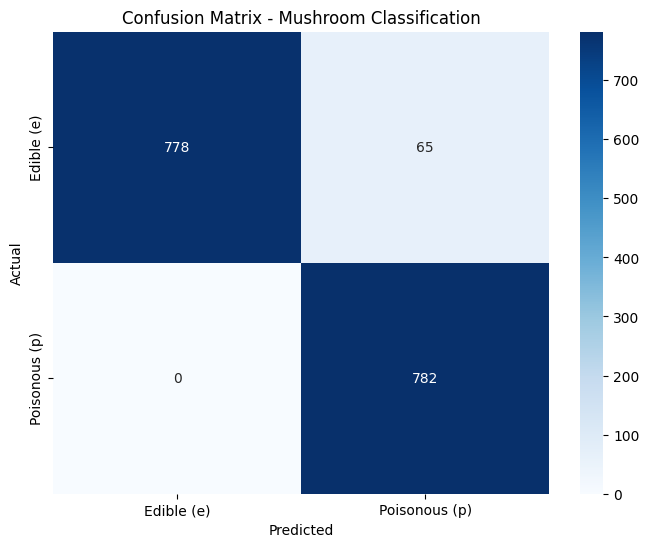

In [77]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible (e)', 'Poisonous (p)'],
            yticklabels=['Edible (e)', 'Poisonous (p)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Mushroom Classification')
plt.show()

In [78]:
# Show class probabilities (like Experiment 5)
print('Class priors:', model.class_prior_)
print('Classes:', model.classes_)

Class priors: [0.51777196 0.48222804]
Classes: ['e' 'p']


## Step 9: Decision Tree Classifier (Additional – Same as Experiment 5)

In [79]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [80]:
# Train Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)  # max_depth to keep it readable
tree_model.fit(X_train, y_train)

# Decision Tree predictions
y_pred_tree = tree_model.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 1.0


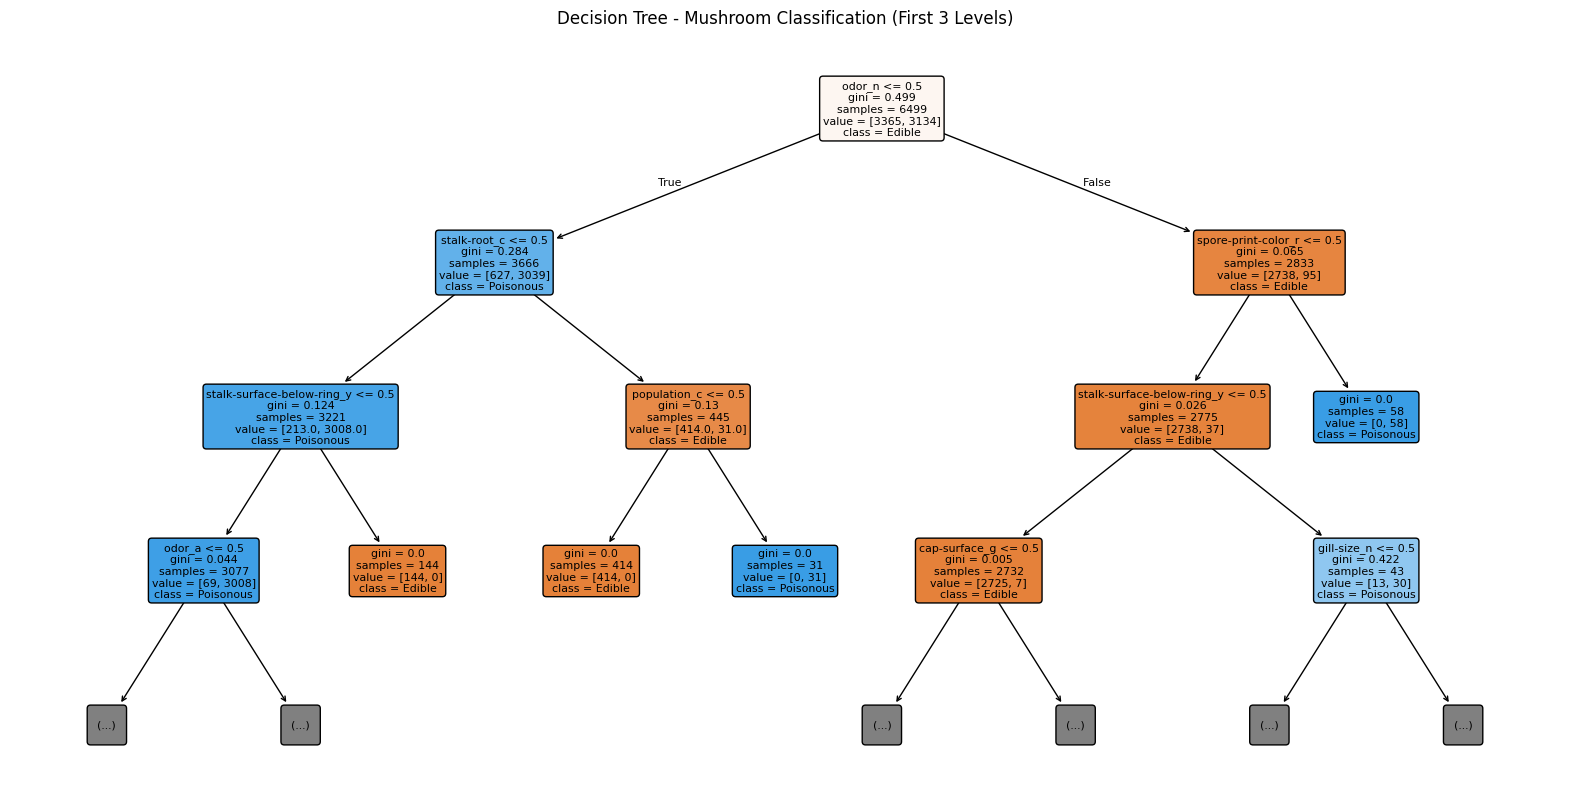

In [81]:
# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=one_hot_encoded.get_feature_names_out(X.columns),
          class_names=['Edible', 'Poisonous'],
          filled=True,
          rounded=True,
          max_depth=3)  # Show only first 3 levels for readability
plt.title('Decision Tree - Mushroom Classification (First 3 Levels)')
plt.show()

## Step 10: Prediction Function (Home Task – Same as Experiment 5)

Function that accepts mushroom features and returns Edible or Poisonous prediction

In [82]:
def predict_mushroom(cap_shape, cap_surface, cap_color, bruises, odor,
                     gill_attachment, gill_spacing, gill_size, gill_color,
                     stalk_shape, stalk_root, stalk_surface_above_ring,
                     stalk_surface_below_ring, stalk_color_above_ring,
                     stalk_color_below_ring, veil_type, veil_color,
                     ring_number, ring_type, spore_print_color,
                     population, habitat):
    """
    Predict if a mushroom is Edible or Poisonous based on its features.
    
    Parameters:
    -----------
    All 22 mushroom characteristics as per the dataset
    
    Returns:
    --------
    str: 'e' for Edible, 'p' for Poisonous
    """
    # Create input DataFrame
    input_data = pd.DataFrame({
        'cap-shape': [cap_shape],
        'cap-surface': [cap_surface],
        'cap-color': [cap_color],
        'bruises': [bruises],
        'odor': [odor],
        'gill-attachment': [gill_attachment],
        'gill-spacing': [gill_spacing],
        'gill-size': [gill_size],
        'gill-color': [gill_color],
        'stalk-shape': [stalk_shape],
        'stalk-root': [stalk_root],
        'stalk-surface-above-ring': [stalk_surface_above_ring],
        'stalk-surface-below-ring': [stalk_surface_below_ring],
        'stalk-color-above-ring': [stalk_color_above_ring],
        'stalk-color-below-ring': [stalk_color_below_ring],
        'veil-type': [veil_type],
        'veil-color': [veil_color],
        'ring-number': [ring_number],
        'ring-type': [ring_type],
        'spore-print-color': [spore_print_color],
        'population': [population],
        'habitat': [habitat]
    })

    # Transform using the fitted encoder
    input_encoded = one_hot_encoded.transform(input_data)

    # Make prediction
    prediction = model.predict(input_encoded)

    # Return readable result
    answer = 'Edible' if prediction[0] == 'e' else 'Poisonous'
    return answer

### Test the Prediction Function with Sample Data

In [83]:
# Test with first sample from dataset
sample = df.iloc[0]
print('Sample features:')
print(sample.iloc[1:].to_dict())
print('Actual class:', 'Edible' if sample['class'] == 'e' else 'Poisonous')

# Predict
result = predict_mushroom(*sample.iloc[1:].values)
print('Prediction:', result)

Sample features:
{'cap-shape': 'x', 'cap-surface': 's', 'cap-color': 'n', 'bruises': 't', 'odor': 'p', 'gill-attachment': 'f', 'gill-spacing': 'c', 'gill-size': 'n', 'gill-color': 'k', 'stalk-shape': 'e', 'stalk-root': 'e', 'stalk-surface-above-ring': 's', 'stalk-surface-below-ring': 's', 'stalk-color-above-ring': 'w', 'stalk-color-below-ring': 'w', 'veil-type': 'p', 'veil-color': 'w', 'ring-number': 'o', 'ring-type': 'p', 'spore-print-color': 'k', 'population': 's', 'habitat': 'u'}
Actual class: Poisonous
Prediction: Poisonous


## Step 11: Model Comparison Summary

In [84]:
# Compare both models
print('=' * 50)
print('MODEL COMPARISON - MUSHROOM CLASSIFICATION')
print('=' * 50)
print(f'Naive Bayes Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}')
print('=' * 50)
print('Dataset Information:')
print(f'- Total samples: {df.shape[0]}')
print(f'- Features: {df.shape[1] - 1} categorical features')
print(f'- Classes: Edible (e), Poisonous (p)')
print(f'- Train/Test split: 80%/20%')
print(f'- Random state: 42 (same as Experiment 5)')

MODEL COMPARISON - MUSHROOM CLASSIFICATION
Naive Bayes Accuracy:  0.9600
Decision Tree Accuracy: 1.0000
Dataset Information:
- Total samples: 8124
- Features: 22 categorical features
- Classes: Edible (e), Poisonous (p)
- Train/Test split: 80%/20%
- Random state: 42 (same as Experiment 5)


## Conclusion

This notebook successfully replicated all operations from Experiment 5 (PlayTennis) on the **Kaggle Mushroom Classification dataset**:

1. Data Loading and EDA (shape, head, null check, describe)
2. Feature-Target split
3. One-Hot Encoding for categorical features
4. Train-Test Split (80/20 with random_state=42)
5. Gaussian Naive Bayes training and evaluation
6. Confusion Matrix visualization
7. Decision Tree classifier
8. Custom prediction function

**Key Difference:** The Mushroom dataset (8,124 samples) is much larger than PlayTennis (14 samples) and has 22 categorical features, making it more realistic for demonstrating Naive Bayes on real-world data.